# The Shark harmonic: the one pattern in the zoo that never pulls back 🦈
### Two overshoots, a completion ZONE — and a real-tape shrug

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_placebo%3F: Busted](https://img.shields.io/badge/Beats_a_placebo%3F-Busted-8b949e?style=flat-square)

Every classic "harmonic pattern" retail charting software draws for you — Gartley, Bat, Butterfly, Crab — shares one habit: somewhere in the middle, price *pulls back* (a retracement) before the pattern completes. The **Shark**, introduced later by Scott Carney as a deliberately "non-standard" 5-point structure, breaks that habit entirely: both of its middle legs **overshoot**, never retrace, and its completion isn't even a single price — it's a whole *zone*, 0.886 to 1.13 times the original move. The nickname is the "5-0" pattern.

So we built a robot that finds every Shark on six liquid tapes over the last 21-25 years — no eyeballing, no cherry-picking — and asked whether fading price the moment it enters that zone would actually have made money.

> 📓 **Plain-language layer.** Want the *t*-stats, the Bonferroni correction and the placebo math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Pivots are a confirmed percentage zig-zag (known only after price reverses enough to lock them in — no look-ahead). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from shark_harmonic import data, strategy as st

PCT = 0.02
HAVE_REAL = data.have_real()
BARS = data.load_basket() if HAVE_REAL else {}
print("real cache present:", HAVE_REAL, "| basket:", data.BASKET)

# frozen headline numbers (mirror of docs/results.md)
R = {'basket': ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA'), 'asof': '2026-06-30', 'n_pivots': 6055, 'n_cand_shark': 103, 'n_shark': 94, 'n_cand_plac': 103, 'n_plac': 97, 'shark': {1: {'hit': 50.0, 'mean': 33.53, 't': 1.34}, 5: {'hit': 54.3, 'mean': 22.81, 't': 0.42}, 10: {'hit': 53.2, 'mean': 8.88, 't': 0.1}}, 'wilson_shark': (44.2, 64.0), 'per_instrument': {'SPY': {'n': 11, 'mean': 181.73, 't': 4.63}, 'QQQ': {'n': 12, 'mean': 112.75, 't': 1.24}, 'AAPL': {'n': 16, 'mean': 59.52, 't': 0.45}, 'MSFT': {'n': 14, 'mean': -46.53, 't': -0.48}, 'TSLA': {'n': 14, 'mean': 82.5, 't': 0.77}, 'NVDA': {'n': 27, 'mean': -98.65, 't': -0.72}}, 'base': {1: {'mean': 1.73, 't': 1.14}, 5: {'mean': -15.0, 't': 0.6}, 10: {'mean': -33.9, 't': 0.53}}, 'n_base': 1880, 'base_per_instrument': {'SPY': {'base_mean': -7.04, 't': 2.57}, 'QQQ': {'base_mean': -23.08, 't': 1.58}, 'AAPL': {'base_mean': 31.08, 't': 0.24}, 'MSFT': {'base_mean': -3.11, 't': -0.37}, 'TSLA': {'base_mean': -0.45, 't': 0.36}, 'NVDA': {'base_mean': -55.65, 't': -0.27}}, 'bonf_n_tests': 7, 'bonf_thr': 2.69, 'bonf_uncorrected': 1, 'bonf_survive': 0, 'timer': {1: {'gross': 33.53, 't_gross': 1.34, 'net5': 23.53, 't5': 0.94, 'net10': 13.53, 't10': 0.54}, 3: {'gross': 31.95, 't_gross': 0.87, 'net5': 21.95, 't5': 0.6, 'net10': 11.95, 't10': 0.33}, 5: {'gross': 22.81, 't_gross': 0.42, 'net5': 12.81, 't5': 0.23, 'net10': 2.81, 't10': 0.05}, 10: {'gross': 8.88, 't_gross': 0.1, 'net5': -1.12, 't5': -0.01, 'net10': -11.12, 't10': -0.12}, 20: {'gross': 32.38, 't_gross': 0.21, 'net5': 22.38, 't5': 0.14, 'net10': 12.38, 't10': 0.08}}, 'plac': {1: {'mean': 45.97, 't': -0.36}, 5: {'mean': -0.68, 't': 0.26}, 10: {'mean': 56.13, 't': -0.42}}, 'plac_per_instrument': {'SPY': {'n': 12, 'mean': 125.53, 'beats': True}, 'QQQ': {'n': 13, 'mean': 117.4, 'beats': False}, 'AAPL': {'n': 14, 'mean': 191.56, 'beats': False}, 'MSFT': {'n': 15, 'mean': -2.84, 'beats': False}, 'TSLA': {'n': 14, 'mean': -29.97, 'beats': True}, 'NVDA': {'n': 29, 'mean': -183.4, 'beats': True}}, 'n_beats_plac': 3, 'syn_null_mean': 0.08, 'syn_null_sd': 1.07, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_planted_mean_rev': 0.7, 'syn_planted_n': 132, 'syn_planted_mean': -92.35, 'syn_planted_t': -5.21, 'fp': {'SPY': 'fc0e2330906f', 'QQQ': '579f714ce50b', 'AAPL': '5d82665ed860', 'MSFT': '740543bb9d77', 'TSLA': 'f8ca92e420b8', 'NVDA': 'bdd3551bb11f'}}


real cache present: True | basket: ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA')


## The answer first

| Question | Answer |
|---|---|
| Does price turn where the Shark says it should? | **Not detectably.** Over a 5-day hold the pattern averages **+23 bps** — small and positive, but the hit rate (54.3%) is a coin flip and the number isn't statistically different from zero. |
| Does it beat a random day with the same directional lean? | **No.** Welch *t* = 0.60 vs a matched-direction random-day baseline — indistinguishable. |
| Does the exact 0.886-1.13 zone matter? | **Not provably.** Move that zone somewhere else on the *identical* pivots and you do about the same (Welch *t* = 0.26, and the real zone only wins on 3/6 tickers). |
| Can you trade it? | **No.** No holding period, from 1 to 20 days, ever clears a basic significance bar, gross or net of costs. |

> A pattern billed as the odd one out — built entirely from overshoots, with a real *zone* instead of a single magic number — still lands exactly where its siblings do: indistinguishable from noise.

## 1 · The claim

> *"Find four swing points X-A-B-C. B must **overshoot** the X-A move by **1.13-1.618 times**, past point X. C must overshoot the A-B move by a further **1.618-2.24 times**, past point B. Neither leg retraces — the structure just keeps extending. Then watch for price to enter the **0.886-1.13** zone of the *original* X-A move: that's the reversal zone, the exhaustion point where the overshoot runs out of steam."*

That's Scott Carney's Shark (*Harmonic Trading, Volume 3*, 2015) — his own description calls it "non-standard" precisely because it breaks from the Gartley-style retracement grid every other pattern in the family uses. It's the reason charting platforms label it separately from the rest of the "harmonic" zoo, and traders treat its completion zone (not a single point) as an extra layer of precision.

## 2 · So what?

If the *only* pattern in the zoo built entirely from overshoots — no retracement leg to hide behind — genuinely marks a reversal, that would be a striking, mechanically testable edge, and arguably more defensible than its retracement-based cousins (a real *zone*, rather than a lucky single number, sounds like it should be more robust). And harmonic trading remains popular precisely because completed patterns look uncanny in hindsight — a trader who already knows the outcome will always find the Shark that worked.

So we removed the human: a mechanical rule finds every qualifying X-A-B-C on the tape, in real time, with no knowledge of the future — then we measure what actually happened once price entered the zone.

## 3 · How would we even know?

- **The basket.** SPY, QQQ, AAPL, MSFT, TSLA, NVDA — six liquid names, daily bars, 2001/2010 → 2026-06-30.
- **The rule, mechanically.** A confirmed zig-zag finds swing pivots (only known once price has reversed enough to lock them in). Every qualifying X-A-B-C projects a D-ZONE; we scan forward up to 120 sessions for the first bar whose range overlaps it.
- **The trade.** Fade at the touch — bet on the reversal the pattern predicts — and measure the forward return.
- **Two honest baselines, announced up front.** (1) A **random-day base rate**: same ticker, same number of trades, same bullish/bearish mix, just on random days — kills the "stocks drift up anyway" confound. (2) A **placebo completion zone**: the identical pivots, but the zone re-centered elsewhere — kills the "any nearby completion zone would work" confound. And because we test six tickers, we **correct for that** (Bonferroni) before calling anything real.

## 4 · The teardown — let's actually look

**First, the headline.** Fade the D-zone touch, hold 5 days, average across every qualifying Shark on the basket.

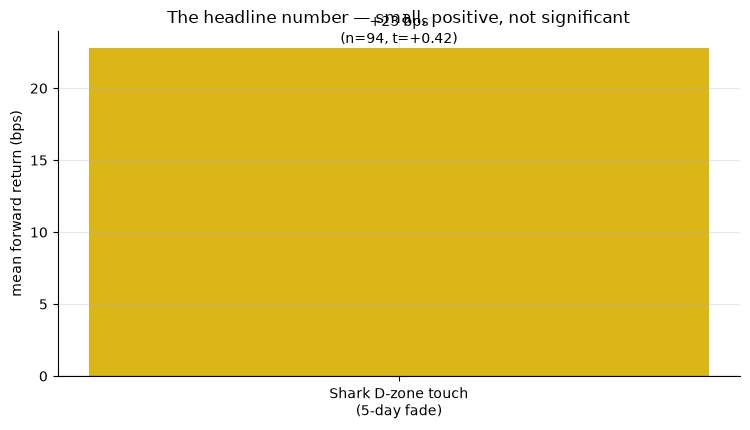

n=94  mean=+22.81bps  t=+0.42


In [2]:
if HAVE_REAL:
    frames = []
    for t in data.BASKET:
        _, _, ledger = st.detect_and_scan(BARS[t], pct=PCT, cost_bps=0.0)
        if not ledger.empty:
            frames.append(ledger)
    SHARK = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    s5 = st.summarize(SHARK, 'ret_gross_5')
    n5, m5, t5 = s5['n'], s5['mean_bps'], s5['t']
else:
    n5, m5, t5 = R['n_shark'], R['shark'][5]['mean'], R['shark'][5]['t']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['Shark D-zone touch\n(5-day fade)'], [m5], color=AMBER, width=.5)
ax.annotate(f'{m5:+.0f} bps\n(n={n5}, t={t5:+.2f})', (0, m5), ha='center',
            va='bottom' if m5 >= 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward return (bps)')
ax.set_title('The headline number — small, positive, not significant')
plt.tight_layout(); plt.show()
print(f'n={n5}  mean={m5:+.2f}bps  t={t5:+.2f}')

**+23 bps** on average, *t* = **0.42** — positive, but a *t* that small could easily be zero. If the Shark's "5-0" zone were a genuine reversal signal, we'd want to see this number stand well clear of noise on its own, before any control is even applied. It doesn't.

**Second, the honest baseline.** Stocks drift up. A random buy on a random day, matched to the same bullish/bearish mix as our Shark trades, earns *something* just from that drift. Does the Shark beat even that?

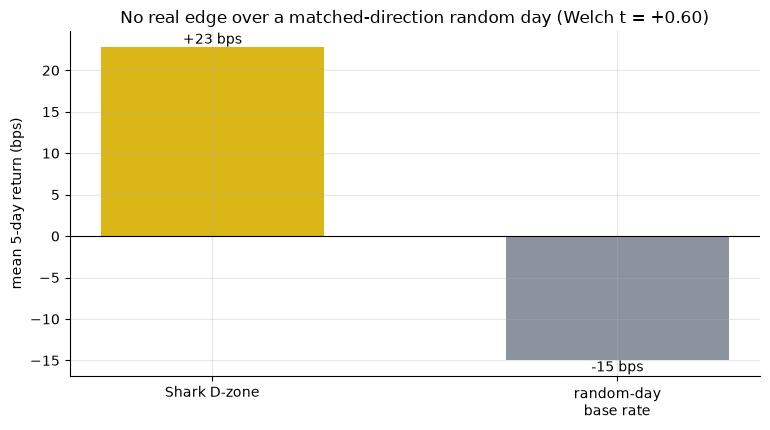

Shark +22.8 bps vs base rate -15.0 bps  Welch t=+0.60


In [3]:
if HAVE_REAL:
    shark_by_t, base_frames = {}, []
    for t in data.BASKET:
        _, _, l = st.detect_and_scan(BARS[t], pct=PCT, cost_bps=0.0)
        shark_by_t[t] = l
        if len(l):
            mix = float((l['reversal_dir'] > 0).mean())
            for s in range(20):
                base_frames.append(st.base_rate_ledger(BARS[t], len(l), mix,
                    seed=st._seed_from(702, t, s)))
    BASE = pd.concat(base_frames, ignore_index=True) if base_frames else pd.DataFrame()
    sb = st.summarize(BASE, 'ret_gross_5')
    bm, wt = sb['mean_bps'], st.welch_t(SHARK['ret_gross_5'], BASE['ret_gross_5'])
else:
    bm, wt = R['base'][5]['mean'], R['base'][5]['t']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['Shark D-zone', 'random-day\nbase rate'], [m5, bm], color=[AMBER, GREY], width=.55)
for i, v in enumerate([m5, bm]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day return (bps)')
ax.set_title(f'No real edge over a matched-direction random day (Welch t = {wt:+.2f})')
plt.tight_layout(); plt.show()
print(f'Shark {m5:+.1f} bps vs base rate {bm:+.1f} bps  Welch t={wt:+.2f}')

The Shark does look a bit better than the random-day baseline (Welch *t* = **0.60**), but that gap is nowhere near the desk's *t* ≥ 2 bar for calling something real. Look at the sample: **94 touches, spread across six stocks, over 21-25 years** — and we tested **six different tickers**.

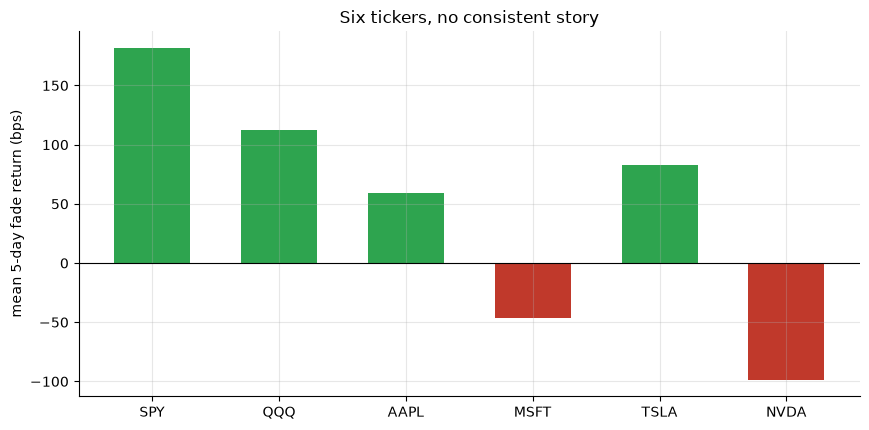

{'SPY': 181.7, 'QQQ': 112.7, 'AAPL': 59.5, 'MSFT': -46.5, 'TSLA': 82.5, 'NVDA': -98.6}


In [4]:
if HAVE_REAL:
    per_t = {t: st.summarize(shark_by_t[t], 'ret_gross_5') for t in data.BASKET}
    tickers = list(data.BASKET)
    means = [per_t[t]['mean_bps'] for t in tickers]
else:
    tickers = list(R['per_instrument'])
    means = [R['per_instrument'][t]['mean'] for t in tickers]
cols = [GREEN if m > 0 else RED for m in means]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(tickers, means, color=cols, width=.6)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day fade return (bps)')
ax.set_title('Six tickers, no consistent story')
plt.tight_layout(); plt.show()
print({t: round(m,1) for t,m in zip(tickers, means)})

Four of six tickers are positive, two negative — SPY's outsized +181.73 bps is the only one that individually clears a naive *t* ≥ 2, and it's built from just 11 events. That's the signature of a thin, noisy sample dominated by one lucky name, not a discovery: correcting properly for having tested six tickers, **0 of 7** results survive.

**Finally, the placebo.** Does the *specific* 0.886-1.13 zone matter, or would any similarly-shaped completion zone have done just as well?

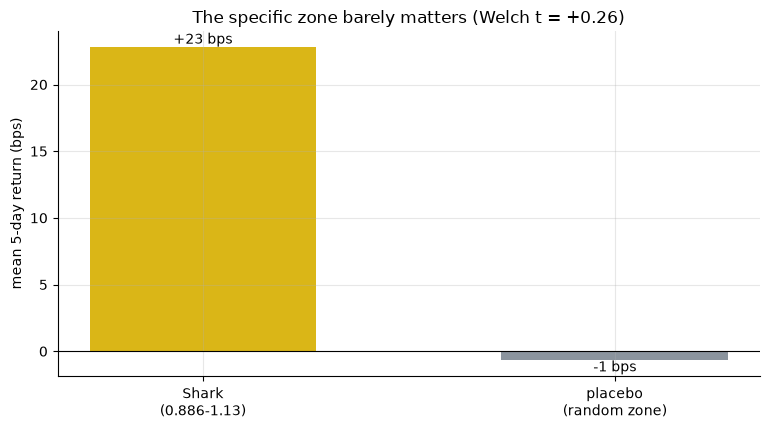

Shark +22.8 bps vs placebo -0.7 bps  Welch t=+0.26


In [5]:
if HAVE_REAL:
    plac_frames = []
    for t in data.BASKET:
        _, _, lp = st.detect_and_scan(BARS[t], pct=PCT, placebo=True, seed=702, cost_bps=0.0)
        if not lp.empty:
            plac_frames.append(lp)
    PLAC = pd.concat(plac_frames, ignore_index=True) if plac_frames else pd.DataFrame()
    sp = st.summarize(PLAC, 'ret_gross_5')
    pm, wtp = sp['mean_bps'], st.welch_t(SHARK['ret_gross_5'], PLAC['ret_gross_5'])
else:
    pm, wtp = R['plac'][5]['mean'], R['plac'][5]['t']
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.bar(['Shark\n(0.886-1.13)', 'placebo\n(random zone)'], [m5, pm],
       color=[AMBER, GREY], width=.55)
for i, v in enumerate([m5, pm]):
    ax.annotate(f'{v:+.0f} bps', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean 5-day return (bps)')
ax.set_title(f'The specific zone barely matters (Welch t = {wtp:+.2f})')
plt.tight_layout(); plt.show()
print(f'Shark {m5:+.1f} bps vs placebo {pm:+.1f} bps  Welch t={wtp:+.2f}')

The Shark's exact **+23 bps** and the placebo's **-1 bps** are barely different — the gap is nowhere near statistically real (Welch *t* = **0.26**), and the real zone only beats its own placebo on **3/6** tickers. The specific 0.886-1.13 band — the Shark's whole selling point over an arbitrary nearby zone — is not doing detectable work.

## 5 · The verdict

- **Signal — None.** The fade is small and positive from the first look (*t* = 0.42), does not beat a matched-direction random day (*t* = 0.60), and fails a six-ticker correction (0/7 survive).
- **Tradability — Mirage.** No hold length clears significance, gross or net; the pattern isn't even monotone with horizon.
- **"Is 0.886-1.13 the Shark's defining edge?" — Busted.** Move the zone elsewhere on the identical pivots and you do about the same (Welch *t* = 0.26).

## 6 · Going further 🚪

- **The general lesson: a fancier geometry doesn't buy you a real edge.** The Shark is structurally the most distinctive pattern in the harmonic zoo — no retracement leg, a genuine completion zone instead of a point — and none of that distinctiveness translates into a detectable reversal on the real tape.
- **Sibling studies:** [468-gartley-harmonic](../../468-gartley-harmonic/), [699-butterfly-harmonic](../../699-butterfly-harmonic/), [700-bat-harmonic](../../700-bat-harmonic/), [701-crab-harmonic](../../701-crab-harmonic/) and [703-cypher-harmonic](../../703-cypher-harmonic/) all reach the same shape of verdict independently, across very different XABCD geometries.

*Think the Shark needs its full "confluence zone" — several overlapping Fibonacci projections converging near D — to work? Show it beats this study's placebo and survives the multiple-comparison correction, then we'll talk.*